## Simulation semestrielle

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 1. Chargement des données enrichies
# ================================
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P5_V2_andrea_nebot/df_all.csv")
df['date_commande'] = pd.to_datetime(df['date_commande'])

# Passage en période semestrielle (H pour half-year)
df['semester'] = df['date_commande'].dt.to_period("2Q")  # chaque semestre = 2 trimestres

# ================================
# 2. Agrégation semestrielle par client
# ================================
df_grouped = df.groupby(['identifiant_unique_client', 'semester']).agg({
    'montant_paiement': ['sum', 'mean'],
    'identifiant_commande': 'nunique',
    'note_avis': ['mean', lambda x: x.notna().mean()],
}).reset_index()

# Renommage colonnes
columns = ['identifiant_unique_client', 'semester',
           'montant_total', 'montant_moyen', 'nombre_commandes', 'note_moyenne', 'taux_avis']
df_grouped.columns = columns

# ================================
# 3. Liste des semestres
# ================================
semesters = sorted(df_grouped['semester'].unique())
variables = ['montant_total', 'montant_moyen', 'nombre_commandes', 'note_moyenne', 'taux_avis']

# ================================
# 4. Simulation temporelle - KMeans
# ================================
results_kmeans = []

for i in range(len(semesters) - 1):
    s1, s2 = semesters[i], semesters[i+1]
    d1 = df_grouped[df_grouped['semester'] == s1].copy()
    d2 = df_grouped[df_grouped['semester'] == s2].copy()

    if len(d1) >= 10 and len(d2) >= 10:
        model1 = KMeans(n_clusters=6, random_state=42)
        model2 = KMeans(n_clusters=6, random_state=42)

        d1['cluster'] = model1.fit_predict(d1[variables])
        d2['cluster'] = model2.fit_predict(d2[variables])

        merged = pd.merge(
            d1[['identifiant_unique_client', 'cluster']],
            d2[['identifiant_unique_client', 'cluster']],
            on='identifiant_unique_client',
            suffixes=(f'_{s1}', f'_{s2}')
        )

        if len(merged) > 0:
            ari = adjusted_rand_score(merged[f'cluster_{s1}'], merged[f'cluster_{s2}'])
            nmi = normalized_mutual_info_score(merged[f'cluster_{s1}'], merged[f'cluster_{s2}'])
            results_kmeans.append({
                'Comparaison': f'{s1} vs {s2}',
                'Nb clients communs': len(merged),
                'ARI': ari,
                'NMI': nmi
            })

# ================================
# 5. Simulation temporelle - HDBSCAN
# ================================
results_hdbscan = []

for i in range(len(semesters) - 1):
    s1, s2 = semesters[i], semesters[i+1]
    d1 = df_grouped[df_grouped['semester'] == s1].copy()
    d2 = df_grouped[df_grouped['semester'] == s2].copy()

    if len(d1) >= 10 and len(d2) >= 10:
        model1 = hdbscan.HDBSCAN(min_cluster_size=10)
        model2 = hdbscan.HDBSCAN(min_cluster_size=10)

        d1['cluster'] = model1.fit_predict(d1[variables])
        d2['cluster'] = model2.fit_predict(d2[variables])

        merged = pd.merge(
            d1[['identifiant_unique_client', 'cluster']],
            d2[['identifiant_unique_client', 'cluster']],
            on='identifiant_unique_client',
            suffixes=(f'_{s1}', f'_{s2}')
        )

        if len(merged) > 0:
            ari = adjusted_rand_score(merged[f'cluster_{s1}'], merged[f'cluster_{s2}'])
            nmi = normalized_mutual_info_score(merged[f'cluster_{s1}'], merged[f'cluster_{s2}'])
            results_hdbscan.append({
                'Comparaison': f'{s1} vs {s2}',
                'Nb clients communs': len(merged),
                'ARI': ari,
                'NMI': nmi
            })

# ================================
# 6. Résultats finaux
# ================================
df_kmeans = pd.DataFrame(results_kmeans)
df_hdbscan = pd.DataFrame(results_hdbscan)

print("\nKMEANS SEGMENTATION STABILITY")
display(df_kmeans)

print("\nHDBSCAN SEGMENTATION STABILITY")
display(df_hdbscan)

# (Optionnel) Fusion tableau comparatif
comparison = df_kmeans.merge(df_hdbscan, on="Comparaison", suffixes=("_KMeans", "_HDBSCAN"))
display(comparison)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11


KMEANS SEGMENTATION STABILITY


,Comparaison,Nb clients communs,ARI,NMI
0,2016Q4 vs 2017Q1,1,1.000000,1.000000
1,2017Q1 vs 2017Q2,50,0.098500,0.121984
2,2017Q2 vs 2017Q3,92,0.134671,0.125903
3,2017Q3 vs 2017Q4,132,0.228603,0.154073
4,2017Q4 vs 2018Q1,131,0.238344,0.138659
5,2018Q1 vs 2018Q2,194,0.216515,0.117449
6,2018Q2 vs 2018Q3,103,0.058538,0.011876



HDBSCAN SEGMENTATION STABILITY


,Comparaison,Nb clients communs,ARI,NMI
0,2016Q4 vs 2017Q1,1,1.000000,1.000000
1,2017Q1 vs 2017Q2,50,0.093188,0.671137
2,2017Q2 vs 2017Q3,92,-0.008640,0.691602
3,2017Q3 vs 2017Q4,132,0.054951,0.789202
4,2017Q4 vs 2018Q1,131,-0.006293,0.759192
5,2018Q1 vs 2018Q2,194,0.063162,0.691118
6,2018Q2 vs 2018Q3,103,0.030547,0.715059


,Comparaison,Nb clients communs_KMeans,ARI_KMeans,NMI_KMeans,Nb clients communs_HDBSCAN,ARI_HDBSCAN,NMI_HDBSCAN
0,2016Q4 vs 2017Q1,1,1.000000,1.000000,1,1.000000,1.000000
1,2017Q1 vs 2017Q2,50,0.098500,0.121984,50,0.093188,0.671137
2,2017Q2 vs 2017Q3,92,0.134671,0.125903,92,-0.008640,0.691602
3,2017Q3 vs 2017Q4,132,0.228603,0.154073,132,0.054951,0.789202
4,2017Q4 vs 2018Q1,131,0.238344,0.138659,131,-0.006293,0.759192
5,2018Q1 vs 2018Q2,194,0.216515,0.117449,194,0.063162,0.691118
6,2018Q2 vs 2018Q3,103,0.058538,0.011876,103,0.030547,0.715059


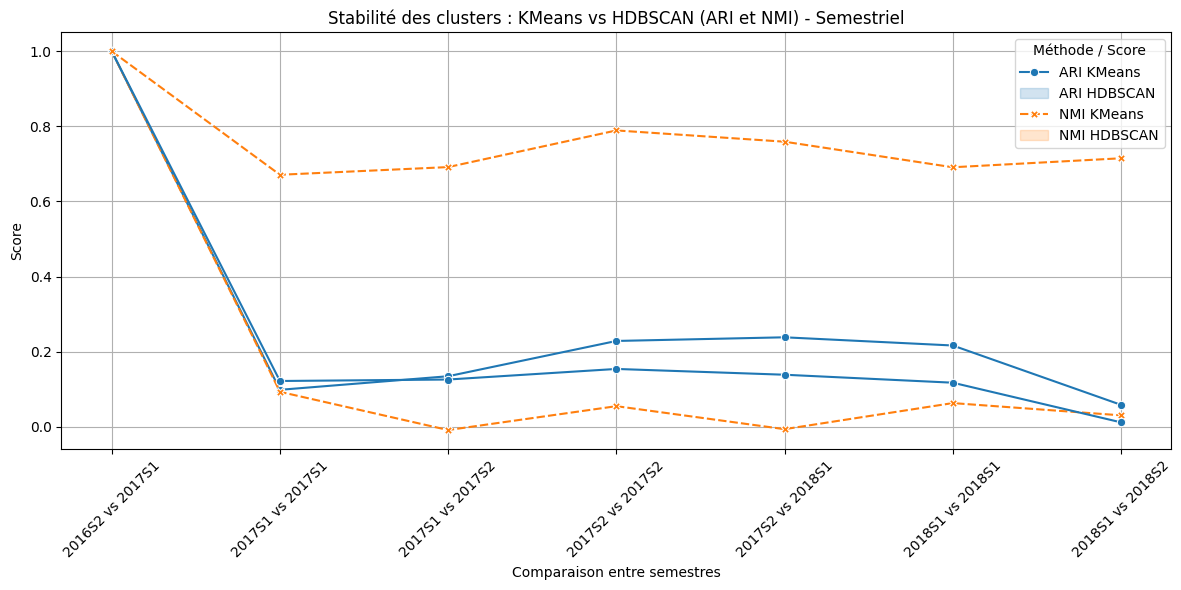

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Données KMeans
data_kmeans = {
    "Comparaison": [
        "2016Q4 vs 2017Q1", "2017Q1 vs 2017Q2", "2017Q2 vs 2017Q3",
        "2017Q3 vs 2017Q4", "2017Q4 vs 2018Q1", "2018Q1 vs 2018Q2", "2018Q2 vs 2018Q3"
    ],
    "Nb clients communs": [1, 50, 92, 132, 131, 194, 103],
    "ARI": [1.000000, 0.098500, 0.134671, 0.228603, 0.238344, 0.216515, 0.058538],
    "NMI": [1.000000, 0.121984, 0.125903, 0.154073, 0.138659, 0.117449, 0.011876],
}

# Données HDBSCAN
data_hdbscan = {
    "Comparaison": [
        "2016Q4 vs 2017Q1", "2017Q1 vs 2017Q2", "2017Q2 vs 2017Q3",
        "2017Q3 vs 2017Q4", "2017Q4 vs 2018Q1", "2018Q1 vs 2018Q2", "2018Q2 vs 2018Q3"
    ],
    "Nb clients communs": [1, 50, 92, 132, 131, 194, 103],
    "ARI": [1.000000, 0.093188, -0.008640, 0.054951, -0.006293, 0.063162, 0.030547],
    "NMI": [1.000000, 0.671137, 0.691602, 0.789202, 0.759192, 0.691118, 0.715059],
}

df_kmeans = pd.DataFrame(data_kmeans)
df_hdbscan = pd.DataFrame(data_hdbscan)

# Fonction pour convertir trimestre en semestre
def quarter_to_semester(q):
    year = int(q[:4])
    quarter = int(q[5])
    semester = (quarter - 1) // 2 + 1
    return f"{year}S{semester}"

# Extraire les deux trimestres
def split_compare(df):
    df[['q1', 'q2']] = df['Comparaison'].str.split(' vs ', expand=True)
    df['s1'] = df['q1'].apply(quarter_to_semester)
    df['s2'] = df['q2'].apply(quarter_to_semester)
    df['Comparaison_semestre'] = df['s1'] + " vs " + df['s2']
    return df

df_kmeans = split_compare(df_kmeans)
df_hdbscan = split_compare(df_hdbscan)

# Fusionner les deux datasets sur comparaison semestrielle
df_merged = pd.merge(
    df_kmeans[['Comparaison_semestre', 'ARI', 'NMI']],
    df_hdbscan[['Comparaison_semestre', 'ARI', 'NMI']],
    on='Comparaison_semestre',
    suffixes=('_KMeans', '_HDBSCAN')
)

# Tracer le graphique
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_merged[['ARI_KMeans', 'ARI_HDBSCAN']], markers=True)
sns.lineplot(data=df_merged[['NMI_KMeans', 'NMI_HDBSCAN']], markers=True, linestyle="--")

plt.xticks(ticks=range(len(df_merged)), labels=df_merged["Comparaison_semestre"], rotation=45)
plt.title("Stabilité des clusters : KMeans vs HDBSCAN (ARI et NMI) - Semestriel")
plt.ylabel("Score")
plt.xlabel("Comparaison entre semestres")
plt.grid(True)
plt.tight_layout()

plt.legend(
    labels=["ARI KMeans", "ARI HDBSCAN", "NMI KMeans", "NMI HDBSCAN"],
    title="Méthode / Score"
)

plt.show()





## Simulation trimestrielle

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 1. Chargement des données enrichies
# ================================
df = pd.read_csv("df_all.csv")
df['date_commande'] = pd.to_datetime(df['date_commande'])
df['quarter'] = df['date_commande'].dt.to_period("Q")

# ================================
# 2. Agrégation trimestrielle par client
# ================================
df_grouped = df.groupby(['identifiant_unique_client', 'quarter']).agg({
    'montant_paiement': ['sum', 'mean'],
    'identifiant_commande': 'nunique',
    'note_avis': ['mean', lambda x: x.notna().mean()],
}).reset_index()

# Renommage colonnes
columns = ['identifiant_unique_client', 'quarter',
           'montant_total', 'montant_moyen', 'nombre_commandes', 'note_moyenne', 'taux_avis']
df_grouped.columns = columns

# ================================
# 3. Liste des trimestres
# ================================
quarters = sorted(df_grouped['quarter'].unique())
variables = ['montant_total', 'montant_moyen', 'nombre_commandes', 'note_moyenne', 'taux_avis']

# ================================
# 4. Simulation temporelle - KMeans
# ================================
results_kmeans = []

for i in range(len(quarters) - 1):
    q1, q2 = quarters[i], quarters[i+1]
    d1 = df_grouped[df_grouped['quarter'] == q1].copy()
    d2 = df_grouped[df_grouped['quarter'] == q2].copy()

    if len(d1) >= 10 and len(d2) >= 10:
        model1 = KMeans(n_clusters=6, random_state=42)
        model2 = KMeans(n_clusters=6, random_state=42)

        d1['cluster'] = model1.fit_predict(d1[variables])
        d2['cluster'] = model2.fit_predict(d2[variables])

        merged = pd.merge(
            d1[['identifiant_unique_client', 'cluster']],
            d2[['identifiant_unique_client', 'cluster']],
            on='identifiant_unique_client',
            suffixes=(f'_{q1}', f'_{q2}')
        )

        if len(merged) > 0:
            ari = adjusted_rand_score(merged[f'cluster_{q1}'], merged[f'cluster_{q2}'])
            nmi = normalized_mutual_info_score(merged[f'cluster_{q1}'], merged[f'cluster_{q2}'])
            results_kmeans.append({
                'Comparaison': f'{q1} vs {q2}',
                'Nb clients communs': len(merged),
                'ARI': ari,
                'NMI': nmi
            })

# ================================
# 5. Simulation temporelle - HDBSCAN
# ================================
results_hdbscan = []

for i in range(len(quarters) - 1):
    q1, q2 = quarters[i], quarters[i+1]
    d1 = df_grouped[df_grouped['quarter'] == q1].copy()
    d2 = df_grouped[df_grouped['quarter'] == q2].copy()

    if len(d1) >= 10 and len(d2) >= 10:
        model1 = hdbscan.HDBSCAN(min_cluster_size=10)
        model2 = hdbscan.HDBSCAN(min_cluster_size=10)

        d1['cluster'] = model1.fit_predict(d1[variables])
        d2['cluster'] = model2.fit_predict(d2[variables])

        merged = pd.merge(
            d1[['identifiant_unique_client', 'cluster']],
            d2[['identifiant_unique_client', 'cluster']],
            on='identifiant_unique_client',
            suffixes=(f'_{q1}', f'_{q2}')
        )

        if len(merged) > 0:
            ari = adjusted_rand_score(merged[f'cluster_{q1}'], merged[f'cluster_{q2}'])
            nmi = normalized_mutual_info_score(merged[f'cluster_{q1}'], merged[f'cluster_{q2}'])
            results_hdbscan.append({
                'Comparaison': f'{q1} vs {q2}',
                'Nb clients communs': len(merged),
                'ARI': ari,
                'NMI': nmi
            })

# ================================
# 6. Résultats finaux
# ================================
df_kmeans = pd.DataFrame(results_kmeans)
df_hdbscan = pd.DataFrame(results_hdbscan)

print("\nKMEANS SEGMENTATION STABILITY")
display(df_kmeans)

print("\nHDBSCAN SEGMENTATION STABILITY")
display(df_hdbscan)

# (Optionnel) Fusion tableau comparatif
comparison = df_kmeans.merge(df_hdbscan, on="Comparaison", suffixes=("_KMeans", "_HDBSCAN"))
display(comparison)



KMEANS SEGMENTATION STABILITY


,Comparaison,Nb clients communs,ARI,NMI
0,2016Q4 vs 2017Q1,1,1.000000,1.000000
1,2017Q1 vs 2017Q2,50,0.098500,0.121984
2,2017Q2 vs 2017Q3,92,0.134671,0.125903
3,2017Q3 vs 2017Q4,132,0.228603,0.154073
4,2017Q4 vs 2018Q1,131,0.238344,0.138659
5,2018Q1 vs 2018Q2,194,0.216515,0.117449
6,2018Q2 vs 2018Q3,103,0.058538,0.011876



HDBSCAN SEGMENTATION STABILITY


,Comparaison,Nb clients communs,ARI,NMI
0,2016Q4 vs 2017Q1,1,1.000000,1.000000
1,2017Q1 vs 2017Q2,50,0.111675,0.682592
2,2017Q2 vs 2017Q3,92,-0.006866,0.709720
3,2017Q3 vs 2017Q4,132,0.032219,0.781217
4,2017Q4 vs 2018Q1,131,-0.019820,0.738400
5,2018Q1 vs 2018Q2,194,0.046156,0.683259
6,2018Q2 vs 2018Q3,103,0.030137,0.715552


,Comparaison,Nb clients communs_KMeans,ARI_KMeans,NMI_KMeans,Nb clients communs_HDBSCAN,ARI_HDBSCAN,NMI_HDBSCAN
0,2016Q4 vs 2017Q1,1,1.000000,1.000000,1,1.000000,1.000000
1,2017Q1 vs 2017Q2,50,0.098500,0.121984,50,0.111675,0.682592
2,2017Q2 vs 2017Q3,92,0.134671,0.125903,92,-0.006866,0.709720
3,2017Q3 vs 2017Q4,132,0.228603,0.154073,132,0.032219,0.781217
4,2017Q4 vs 2018Q1,131,0.238344,0.138659,131,-0.019820,0.738400
5,2018Q1 vs 2018Q2,194,0.216515,0.117449,194,0.046156,0.683259
6,2018Q2 vs 2018Q3,103,0.058538,0.011876,103,0.030137,0.715552


C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


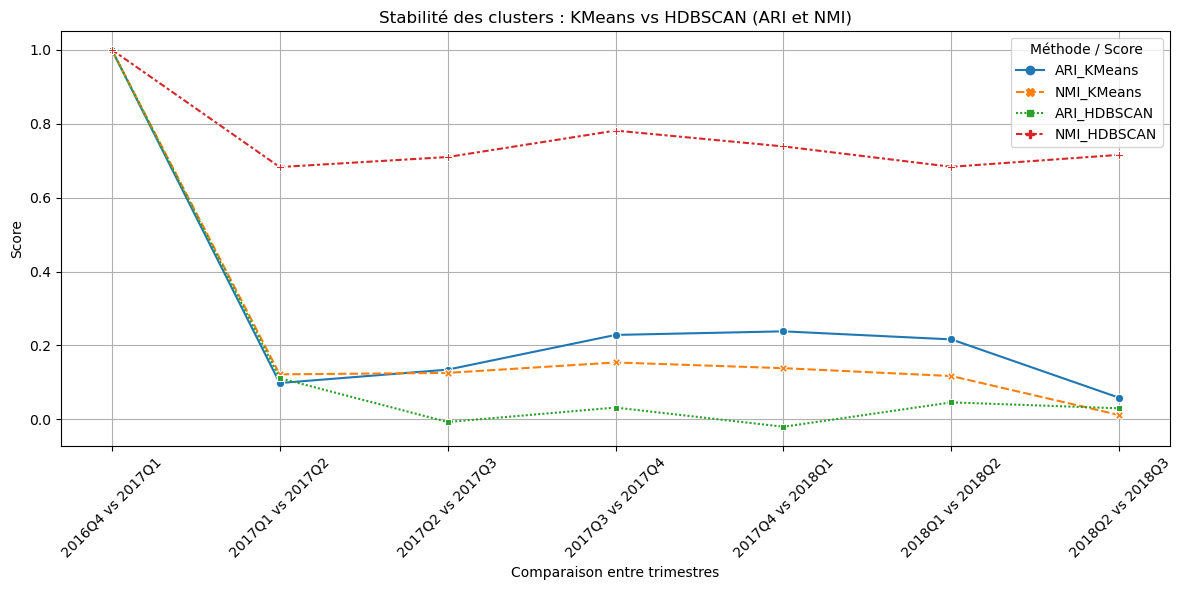

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Données
data = {
    "Comparaison": [
        "2016Q4 vs 2017Q1", "2017Q1 vs 2017Q2", "2017Q2 vs 2017Q3",
        "2017Q3 vs 2017Q4", "2017Q4 vs 2018Q1", "2018Q1 vs 2018Q2", "2018Q2 vs 2018Q3"
    ],
    "ARI_KMeans": [1.000, 0.0985, 0.1347, 0.2286, 0.2383, 0.2165, 0.0585],
    "NMI_KMeans": [1.000, 0.1220, 0.1259, 0.1541, 0.1387, 0.1174, 0.0119],
    "ARI_HDBSCAN": [1.000, 0.1117, -0.0069, 0.0322, -0.0198, 0.0462, 0.0301],
    "NMI_HDBSCAN": [1.000, 0.6826, 0.7097, 0.7812, 0.7384, 0.6833, 0.7156],
}

df = pd.DataFrame(data)

# Création du graphique
plt.figure(figsize=(12, 6))
sns.lineplot(data=df.drop(columns=["Comparaison"]), markers=True)
plt.xticks(ticks=range(len(df)), labels=df["Comparaison"], rotation=45)
plt.title("Stabilité des clusters : KMeans vs HDBSCAN (ARI et NMI)")
plt.ylabel("Score")
plt.xlabel("Comparaison entre trimestres")
plt.grid(True)
plt.tight_layout()
plt.legend(title="Méthode / Score")
plt.show()


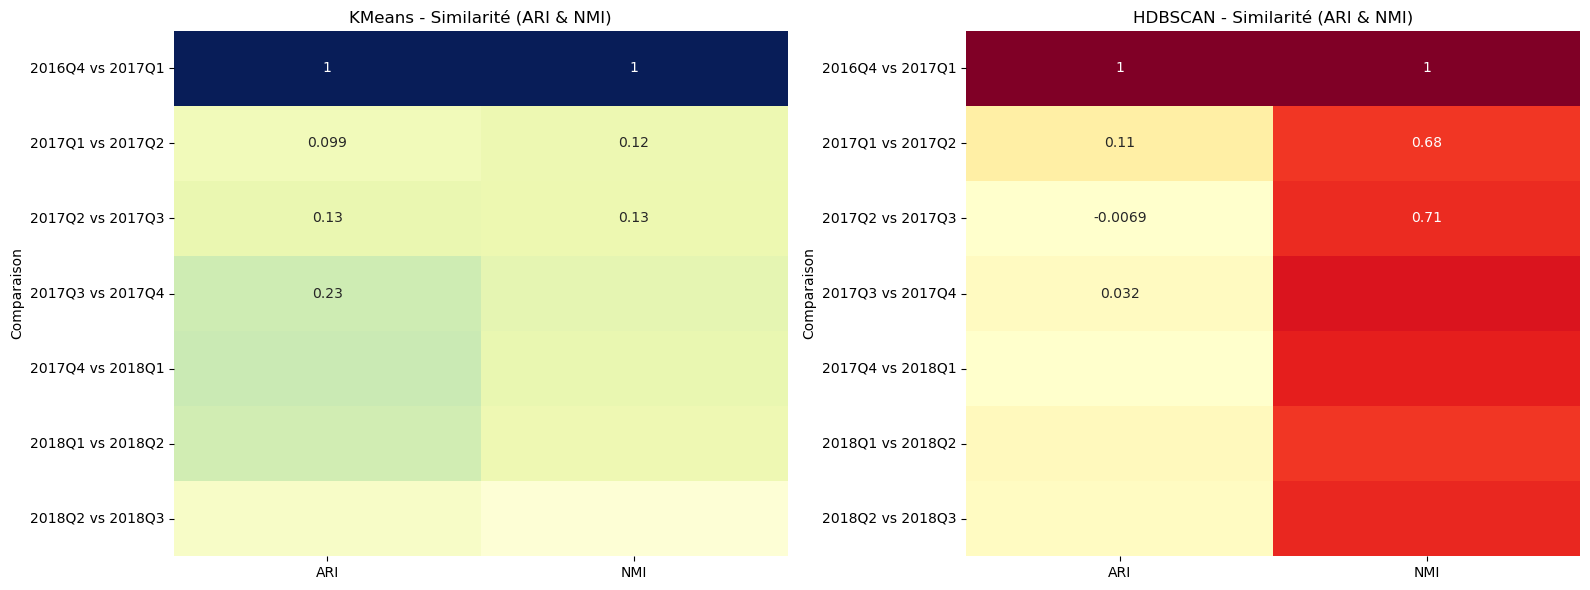

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Données structurées en format long
data = {
    "Comparaison": [
        "2016Q4 vs 2017Q1", "2017Q1 vs 2017Q2", "2017Q2 vs 2017Q3",
        "2017Q3 vs 2017Q4", "2017Q4 vs 2018Q1", "2018Q1 vs 2018Q2", "2018Q2 vs 2018Q3"
    ],
    "ARI_KMeans": [1.000, 0.0985, 0.1347, 0.2286, 0.2383, 0.2165, 0.0585],
    "NMI_KMeans": [1.000, 0.1220, 0.1259, 0.1541, 0.1387, 0.1174, 0.0119],
    "ARI_HDBSCAN": [1.000, 0.1117, -0.0069, 0.0322, -0.0198, 0.0462, 0.0301],
    "NMI_HDBSCAN": [1.000, 0.6826, 0.7097, 0.7812, 0.7384, 0.6833, 0.7156],
}

df = pd.DataFrame(data)

# Format long pour heatmap
df_kmeans = df[["Comparaison", "ARI_KMeans", "NMI_KMeans"]].set_index("Comparaison").rename(columns={"ARI_KMeans": "ARI", "NMI_KMeans": "NMI"})
df_hdbscan = df[["Comparaison", "ARI_HDBSCAN", "NMI_HDBSCAN"]].set_index("Comparaison").rename(columns={"ARI_HDBSCAN": "ARI", "NMI_HDBSCAN": "NMI"})

# Affichage côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(df_kmeans, annot=True, cmap="YlGnBu", cbar=False, vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("KMeans - Similarité (ARI & NMI)")
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(df_hdbscan, annot=True, cmap="YlOrRd", cbar=False, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("HDBSCAN - Similarité (ARI & NMI)")
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


## Simulation mensuelle

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 1. Chargement des données enrichies
# ================================
df = pd.read_csv("df_all.csv")
df['date_commande'] = pd.to_datetime(df['date_commande'])
df['month'] = df['date_commande'].dt.to_period("M")  # agrégation mensuelle

# ================================
# 2. Agrégation mensuelle par client
# ================================
df_grouped = df.groupby(['identifiant_unique_client', 'month']).agg({
    'montant_paiement': ['sum', 'mean'],
    'identifiant_commande': 'nunique',
    'note_avis': ['mean', lambda x: x.notna().mean()],
}).reset_index()

# Renommage colonnes
columns = ['identifiant_unique_client', 'month',
           'montant_total', 'montant_moyen', 'nombre_commandes', 'note_moyenne', 'taux_avis']
df_grouped.columns = columns

# ================================
# 3. Liste des mois
# ================================
months = sorted(df_grouped['month'].unique())
variables = ['montant_total', 'montant_moyen', 'nombre_commandes', 'note_moyenne', 'taux_avis']

# ================================
# 4. Simulation temporelle - KMeans
# ================================
results_kmeans = []

for i in range(len(months) - 1):
    m1, m2 = months[i], months[i+1]
    d1 = df_grouped[df_grouped['month'] == m1].copy()
    d2 = df_grouped[df_grouped['month'] == m2].copy()

    if len(d1) >= 10 and len(d2) >= 10:
        model1 = KMeans(n_clusters=6, random_state=42)
        model2 = KMeans(n_clusters=6, random_state=42)

        d1['cluster'] = model1.fit_predict(d1[variables])
        d2['cluster'] = model2.fit_predict(d2[variables])

        merged = pd.merge(
            d1[['identifiant_unique_client', 'cluster']],
            d2[['identifiant_unique_client', 'cluster']],
            on='identifiant_unique_client',
            suffixes=(f'_{m1}', f'_{m2}')
        )

        if len(merged) > 0:
            ari = adjusted_rand_score(merged[f'cluster_{m1}'], merged[f'cluster_{m2}'])
            nmi = normalized_mutual_info_score(merged[f'cluster_{m1}'], merged[f'cluster_{m2}'])
            results_kmeans.append({
                'Comparaison': f'{m1} vs {m2}',
                'Nb clients communs': len(merged),
                'ARI': ari,
                'NMI': nmi
            })

# ================================
# 5. Simulation temporelle - HDBSCAN
# ================================
results_hdbscan = []

for i in range(len(months) - 1):
    m1, m2 = months[i], months[i+1]
    d1 = df_grouped[df_grouped['month'] == m1].copy()
    d2 = df_grouped[df_grouped['month'] == m2].copy()

    if len(d1) >= 10 and len(d2) >= 10:
        model1 = hdbscan.HDBSCAN(min_cluster_size=10)
        model2 = hdbscan.HDBSCAN(min_cluster_size=10)

        d1['cluster'] = model1.fit_predict(d1[variables])
        d2['cluster'] = model2.fit_predict(d2[variables])

        merged = pd.merge(
            d1[['identifiant_unique_client', 'cluster']],
            d2[['identifiant_unique_client', 'cluster']],
            on='identifiant_unique_client',
            suffixes=(f'_{m1}', f'_{m2}')
        )

        if len(merged) > 0:
            ari = adjusted_rand_score(merged[f'cluster_{m1}'], merged[f'cluster_{m2}'])
            nmi = normalized_mutual_info_score(merged[f'cluster_{m1}'], merged[f'cluster_{m2}'])
            results_hdbscan.append({
                'Comparaison': f'{m1} vs {m2}',
                'Nb clients communs': len(merged),
                'ARI': ari,
                'NMI': nmi
            })

# ================================
# 6. Résultats finaux
# ================================
df_kmeans = pd.DataFrame(results_kmeans)
df_hdbscan = pd.DataFrame(results_hdbscan)

print("\nKMEANS SEGMENTATION STABILITY")
display(df_kmeans)

print("\nHDBSCAN SEGMENTATION STABILITY")
display(df_hdbscan)

# (Optionnel) Fusion tableau comparatif
comparison = df_kmeans.merge(df_hdbscan, on="Comparaison", suffixes=("_KMeans", "_HDBSCAN"))
display(comparison)



KMEANS SEGMENTATION STABILITY


,Comparaison,Nb clients communs,ARI,NMI
0,2017-01 vs 2017-02,3,1.000000,1.000000
1,2017-02 vs 2017-03,4,1.000000,1.000000
2,2017-03 vs 2017-04,13,0.102564,0.147259
3,2017-04 vs 2017-05,14,0.003407,0.138407
4,2017-05 vs 2017-06,17,-0.136077,0.065194
5,2017-06 vs 2017-07,17,-0.004792,0.245460
6,2017-07 vs 2017-08,23,0.491713,0.388663
7,2017-08 vs 2017-09,32,0.190253,0.166826
8,2017-09 vs 2017-10,32,0.107930,0.052254
9,2017-10 vs 2017-11,37,0.116968,0.060750



HDBSCAN SEGMENTATION STABILITY


,Comparaison,Nb clients communs,ARI,NMI
0,2017-01 vs 2017-02,3,0.000000,0.733680
1,2017-02 vs 2017-03,4,0.000000,0.857143
2,2017-03 vs 2017-04,13,0.062847,0.784243
3,2017-04 vs 2017-05,14,-0.119889,0.561830
4,2017-05 vs 2017-06,17,0.110954,0.697210
5,2017-06 vs 2017-07,17,-0.009901,0.742351
6,2017-07 vs 2017-08,23,-0.009219,0.742120
7,2017-08 vs 2017-09,32,0.026663,0.675751
8,2017-09 vs 2017-10,32,0.183555,0.867145
9,2017-10 vs 2017-11,37,-0.046342,0.704315


,Comparaison,Nb clients communs_KMeans,ARI_KMeans,NMI_KMeans,Nb clients communs_HDBSCAN,ARI_HDBSCAN,NMI_HDBSCAN
0,2017-01 vs 2017-02,3,1.000000,1.000000,3,0.000000,0.733680
1,2017-02 vs 2017-03,4,1.000000,1.000000,4,0.000000,0.857143
2,2017-03 vs 2017-04,13,0.102564,0.147259,13,0.062847,0.784243
3,2017-04 vs 2017-05,14,0.003407,0.138407,14,-0.119889,0.561830
4,2017-05 vs 2017-06,17,-0.136077,0.065194,17,0.110954,0.697210
5,2017-06 vs 2017-07,17,-0.004792,0.245460,17,-0.009901,0.742351
6,2017-07 vs 2017-08,23,0.491713,0.388663,23,-0.009219,0.742120
7,2017-08 vs 2017-09,32,0.190253,0.166826,32,0.026663,0.675751
8,2017-09 vs 2017-10,32,0.107930,0.052254,32,0.183555,0.867145
9,2017-10 vs 2017-11,37,0.116968,0.060750,37,-0.046342,0.704315


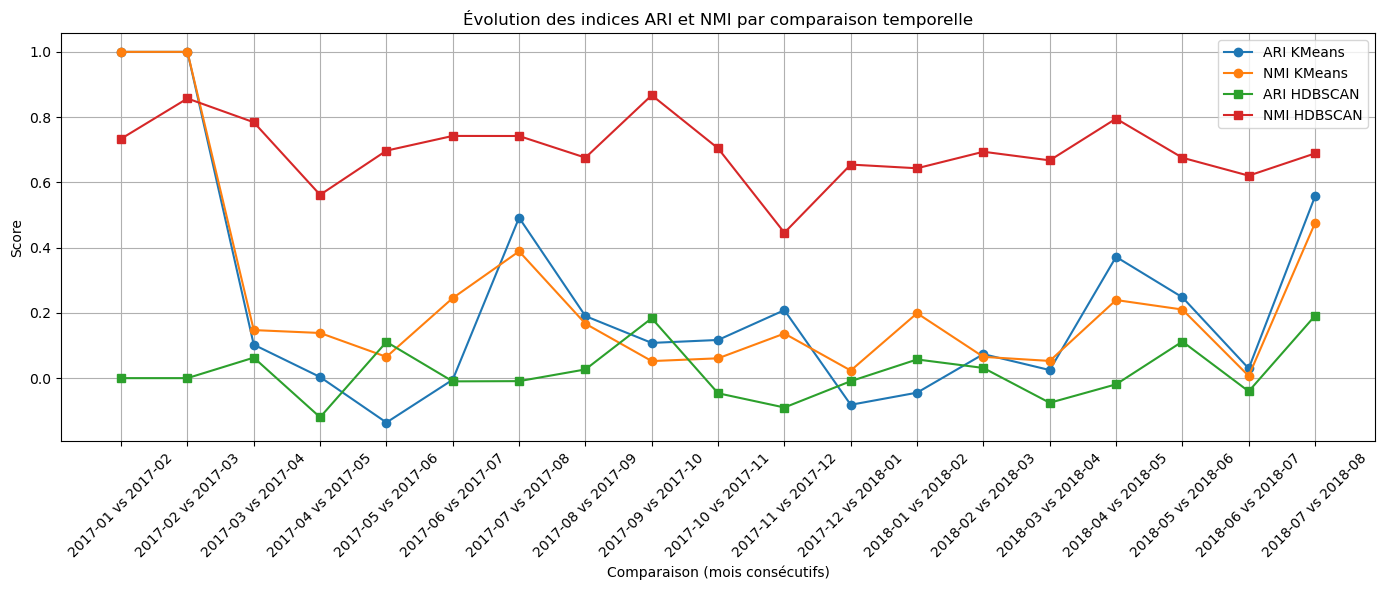

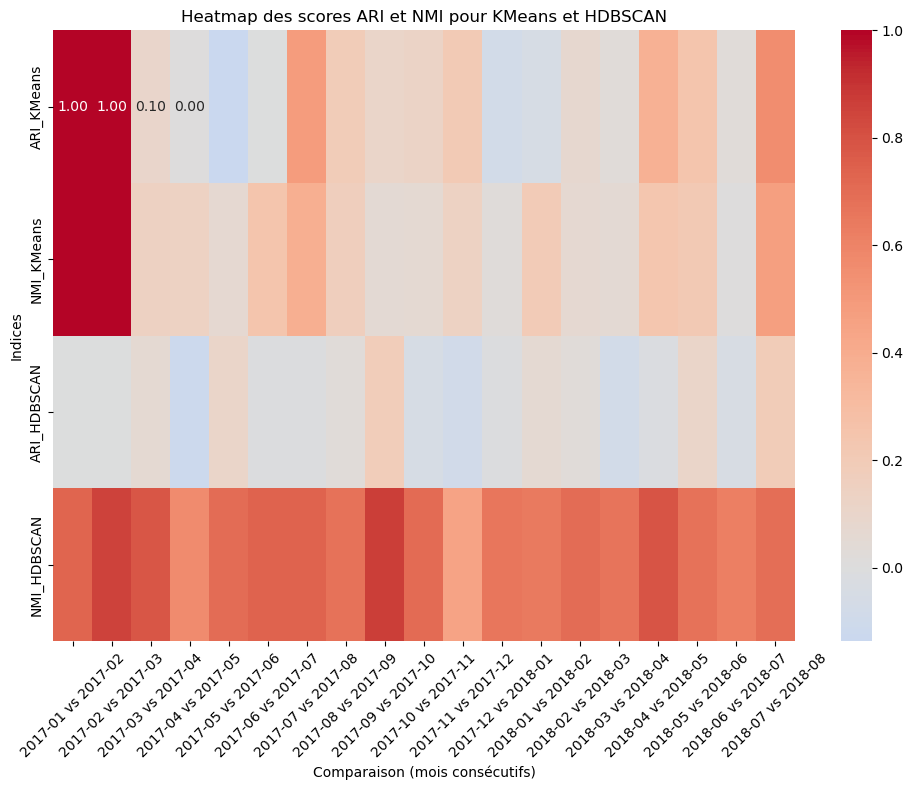

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tes données sous forme de DataFrame
data = {
    "Comparaison": [
        "2017-01 vs 2017-02", "2017-02 vs 2017-03", "2017-03 vs 2017-04",
        "2017-04 vs 2017-05", "2017-05 vs 2017-06", "2017-06 vs 2017-07",
        "2017-07 vs 2017-08", "2017-08 vs 2017-09", "2017-09 vs 2017-10",
        "2017-10 vs 2017-11", "2017-11 vs 2017-12", "2017-12 vs 2018-01",
        "2018-01 vs 2018-02", "2018-02 vs 2018-03", "2018-03 vs 2018-04",
        "2018-04 vs 2018-05", "2018-05 vs 2018-06", "2018-06 vs 2018-07",
        "2018-07 vs 2018-08"
    ],
    "Nb clients communs_KMeans": [3,4,13,14,17,17,23,32,32,37,41,15,26,25,32,45,39,25,36],
    "ARI_KMeans": [1,1,0.102564,0.003407,-0.136077,-0.004792,0.491713,0.190253,0.10793,0.116968,0.208409,-0.081718,-0.044536,0.073584,0.024739,0.371694,0.24777,0.029575,0.557139],
    "NMI_KMeans": [1,1,0.147259,0.138407,0.065194,0.24546,0.388663,0.166826,0.052254,0.06075,0.136676,0.023312,0.198907,0.06519,0.052721,0.239388,0.210255,0.006653,0.475422],
    "Nb clients communs_HDBSCAN": [3,4,13,14,17,17,23,32,32,37,41,15,26,25,32,45,39,25,36],
    "ARI_HDBSCAN": [0,0,0.062847,-0.119889,0.110954,-0.009901,-0.009219,0.026663,0.183555,-0.046342,-0.090013,-0.009302,0.057232,0.031203,-0.075565,-0.019039,0.112097,-0.040438,0.191146],
    "NMI_HDBSCAN": [0.73368,0.857143,0.784243,0.56183,0.69721,0.742351,0.74212,0.675751,0.867145,0.704315,0.445699,0.654553,0.643251,0.693871,0.667461,0.795366,0.675517,0.620567,0.688803],
}

df = pd.DataFrame(data)

# --------- LINEPLOTS ARI & NMI ---------
plt.figure(figsize=(14, 6))
plt.plot(df['Comparaison'], df['ARI_KMeans'], marker='o', label='ARI KMeans')
plt.plot(df['Comparaison'], df['NMI_KMeans'], marker='o', label='NMI KMeans')
plt.plot(df['Comparaison'], df['ARI_HDBSCAN'], marker='s', label='ARI HDBSCAN')
plt.plot(df['Comparaison'], df['NMI_HDBSCAN'], marker='s', label='NMI HDBSCAN')
plt.xticks(rotation=45)
plt.title("Évolution des indices ARI et NMI par comparaison temporelle")
plt.ylabel("Score")
plt.xlabel("Comparaison (mois consécutifs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --------- HEATMAP ---------
# On construit un DataFrame pour heatmap
heatmap_data = df.set_index('Comparaison')[['ARI_KMeans', 'NMI_KMeans', 'ARI_HDBSCAN', 'NMI_HDBSCAN']]

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data.T, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Heatmap des scores ARI et NMI pour KMeans et HDBSCAN")
plt.xlabel("Comparaison (mois consécutifs)")
plt.ylabel("Indices")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


La courbe montre l’évolution de ARI et NMI sur le temps par méthode.

La heatmap permet de visualiser les valeurs positives/négatives et les différences entre KMeans et

## Analyse des résultats mensuels vs trimestriels

| Métriques principales               | KMeans                                                                     | HDBSCAN                                                                                |
| ----------------------------------- | -------------------------------------------------------------------------- | -------------------------------------------------------------------------------------- |
| ARI (Adjusted Rand Index)           | Souvent proche de 0, avec quelques pics (\~0.5) sur certains mois          | Généralement proche de 0 voire négatif sur certains mois                               |
| NMI (Normalized Mutual Information) | Faible (souvent <0.4), sauf très bons cas initiaux à 1                     | Globalement plus élevé (souvent >0.6), donc meilleure stabilité d’information partagée |
| Nb clients communs                  | Plus faible mensuellement (3-45) mais plus élevé trimestriellement (1-194) | Même tendance                                                                          |


ARI mesure la similarité entre deux segmentations, corrigée pour le hasard. 1 = parfait, 0 = segmentation indépendante, négatif = moins bon que hasard.

NMI mesure la mutualité d'information entre clusterings, variant de 0 à 1, plus élevé = meilleure similarité.

## Préconisations:

### Pourquoi privilégier une mise à jour trimestrielle plutôt que mensuelle ?
1.Stabilité insuffisante mensuellement

Les résultats mensuels montrent des ARI souvent très faibles ou même négatifs, indiquant que la segmentation varie beaucoup d’un mois sur l’autre. Cette instabilité signifie que refaire une segmentation chaque mois peut créer de la confusion dans l’utilisation métier :

Trop de changements brusques dans les segments d’un mois à l’autre.

Difficulté pour l’équipe marketing à suivre et exploiter les segments.

2.Nombre de clients communs faible entre mois consécutifs

Par exemple, sur certaines comparaisons mensuelles, le nombre de clients communs entre deux mois est très faible (3 à 45). Cette faible intersection rend la comparaison et la stabilité des clusters difficile à analyser.

Cela reflète une faible récurrence des commandes client d’un mois sur l’autre, rendant les clusters mensuels moins représentatifs.

3.Qualité d’information meilleure sur une période plus longue

Sur les périodes trimestrielles, on a plus de clients communs (ex: 50 à 194), donc plus de données pour construire des clusters robustes.

L’ARI trimestriel, même s’il reste faible, est globalement plus stable qu’au niveau mensuel, et la NMI est plus haute, traduisant une meilleure conservation de la structure des segments.

4.Temps et ressources de calcul optimisés

Réentraîner le modèle tous les mois est coûteux en temps de calcul et ressources, et cela peut entraîner une surcharge pour l’équipe marketing (adaptation trop fréquente).

Travailler sur des périodes plus longues réduit la fréquence des mises à jour sans perdre en pertinence.

5.Alignement avec les cycles business et marketing

Les campagnes marketing sont souvent planifiées sur plusieurs mois. Une segmentation trimestrielle correspond mieux à la planification, évitant des ajustements trop fréquents.

Permet de stabiliser les campagnes et d’analyser les impacts avant de refaire une segmentation.

Choix de la fréquence de mise à jour de la segmentation : trimestrielle vs mensuelle

Après analyse des résultats de stabilité de la segmentation sur des périodes mensuelles et trimestrielles, il apparaît que la mise à jour mensuelle présente une trop grande variabilité. Les indices ARI mensuels sont souvent faibles voire négatifs, traduisant des changements importants dans la structure des segments d’un mois à l’autre, ce qui complique leur exploitation par l’équipe marketing.

De plus, le faible nombre de clients communs entre mois consécutifs limite la robustesse des clusters mensuels, rendant la segmentation moins fiable.

À l’inverse, la segmentation trimestrielle bénéficie d’un nombre de clients communs plus élevé, assurant une meilleure stabilité des clusters. Les mesures de similarité (ARI, NMI) y sont globalement plus favorables, ce qui garantit une segmentation plus cohérente et exploitable sur le moyen terme.

Enfin, la fréquence trimestrielle optimise les ressources de calcul et s’aligne mieux avec les cycles de planification marketing, évitant des mises à jour trop fréquentes qui pourraient nuire à la lisibilité et à l’efficacité des campagnes.

En conclusion, une mise à jour trimestrielle constitue un compromis optimal entre réactivité, stabilité et simplicité d’utilisation, garantissant à Olist une segmentation fiable et actionnable pour ses équipes.

| **Critères**                          | **Mise à jour Mensuelle**                                      | **Mise à jour Trimestrielle**                                | **Mise à jour Semestrielle**                                          |
| ------------------------------------- | -------------------------------------------------------------- | ------------------------------------------------------------ | --------------------------------------------------------------------- |
| **Stabilité des segments (ARI, NMI)** | Faible, indices ARI souvent négatifs ou très bas               | Plus stable, ARI modéré, NMI plus élevé                      | Moins stable qu’en trimestriel, indices variables                     |
| **Nombre de clients communs**         | Faible (3 à 45 clients communs)                                | Plus élevé (50 à 194 clients communs)                        | Comparable au trimestriel mais parfois moins stable                   |
| **Représentativité des clusters**     | Faible, forte variabilité liée à la faible récurrence client   | Bonne, clusters plus robustes grâce à plus de données        | Variable, mais moins fréquente donc moins réactive                    |
| **Coût en ressources et temps**       | Élevé, recalculs fréquents, surcharge possible                 | Modéré, équilibre entre fréquence et coût                    | Faible, peu de recalculs mais moins réactif                           |
| **Adaptation aux cycles marketing**   | Faible, trop fréquente, rend difficile la planification        | Bonne, alignée avec les cycles de campagne de plusieurs mois | Moyenne, mise à jour trop espacée pour ajustements rapides            |
| **Pertinence métier & exploitation**  | Difficile, changements brusques complexifient l’usage          | Optimale, stabilité et réactivité adaptées                   | Moins adaptée, possible retard dans la prise en compte des évolutions |
| **Recommandation**                    | Non recommandée pour segmentation client stable et exploitable | Recommandée comme meilleur compromis                         | Possible si peu de changements attendus sur la période                |
